## Ground Truth Generation

In [1]:
%pip install networkx matplotlib graphviz pygraphviz

Note: you may need to restart the kernel to use updated packages.


In [6]:
import random
import graphviz
import networkx as nx
import matplotlib.pyplot as plt
import pygraphviz
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

### DAG Generation

In [ ]:
#min in-degree?
def generate_dag(
    n_nodes: int,
    max_in_degree: int,
    p_extra_edges: float = 0.0,
    seed: int | None = None
):
    rng = random.Random(seed)
    nodes = [f"X_{i}" for i in range(n_nodes)]

    # Random topological order
    order = nodes[:]
    rng.shuffle(order)
    position = {node: i for i, node in enumerate(order)}

    edges = []
    parents = {node: set() for node in nodes}

    # Backbone - Ensure weak connectivity
    for i in range(1, n_nodes):
        child = order[i]
        parent = rng.choice(order[:i])
        parents[child].add(parent)
        edges.append((parent, child))

    # Extra edges
    for child in order:
        possible_parents = [
            p for p in order[:position[child]]
            if p not in parents[child]
        ]
        rng.shuffle(possible_parents)
        for parent in possible_parents:
            if len(parents[child]) >= max_in_degree:
                break
            if rng.random() < p_extra_edges:
                parents[child].add(parent)
                edges.append((parent, child))

    return edges
 

### DAG Display

In [4]:
def display_dag(edges):
    G = nx.DiGraph()
    G.add_edges_from(edges)

    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")  # needs pygraphviz
    

    # But for a true hierarchical layout without graphviz:
    for layer, nodes in enumerate(nx.topological_generations(G)):
        for i, node in enumerate(nodes):
            pos[node] = (i - len(nodes)/2, -layer)

    nx.draw(G, pos, with_labels=True, node_color="lightyellow",
            edgecolors="black", node_size=1000, arrowsize=15)
    plt.show()  

## Test

Edges: [('X_7', 'X_4'), ('X_4', 'X_3'), ('X_7', 'X_6'), ('X_7', 'X_5'), ('X_5', 'X_2'), ('X_2', 'X_0'), ('X_6', 'X_1'), ('X_7', 'X_3'), ('X_4', 'X_2'), ('X_3', 'X_2')]
Number of edges: 10


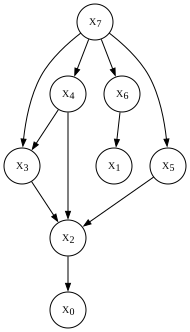

In [22]:
N_NODES = 8

edges = generate_dag(
    n_nodes=N_NODES,
    max_in_degree=3,
    p_extra_edges=0.2,
)

print(f"Edges: {edges}")
print(f"Number of edges: {len(edges)}")

dot = graphviz.Digraph(
    graph_attr={"rankdir": "TB"},
    node_attr={"width": "0.5", "height": "0.5", "fontsize": "10"},
    edge_attr={"arrowsize": "0.7"},
)

for u, v in edges:
    dot.edge(u, v)

for i in range(N_NODES):
    node_id = f"X_{i}"
    dot.node(node_id, label=f"<X<SUB>{i}</SUB>>")

dot